In [1]:
from typing import Dict, Any
import matplotlib.pyplot as plt
from model_ranking import (
    get_classification_dataloader,
    ClassificationLoaderConfig,
)

INFO: P [MainThread] 2025-09-09 17:15:53,464 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/predictor.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/predictor.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [11]:
val_loader: Dict[str, Any] = {
    'patch_position': {
        'patch_pos_path': '/g/kreshuk/talks/data/epfl/classification_patches/epfl_resized_01_80x80.h5',
        'patch_pos_key': 'validation',
        'roi': None,
        'rnd_seed': None,
        'n_unique_patches': None,
        'slice_offset': None
    },
    'aug_config': None,
    'dataset': {
        'raw_path': '/scratch/talks/data/EPFL/val.h5',
        'raw_key': 'raw',
        'mask_path': '/scratch/talks/data/EPFL/val.h5',
        'mask_key': 'labels',
        'patch_shape': [1, 80, 80],
        'repeat_patches': False,
        'sample_patches': False,
        'patch_rnd_seed': None,
        'mask_return_mode': False,
        'patch_return_mode': False
    },
    'n_samples': 4,
    'ndim': 2,
    'batch_size': 2,
    'shuffle': True,
    'loader_rnd_seed': 42,
    'num_workers': 16
}
loader_cfg = ClassificationLoaderConfig.model_validate(val_loader)

In [12]:
loader = get_classification_dataloader(loader_cfg)

number of unique patches loaded: 1271
Number of patches in the dataset: 4


Epoch 0
torch.Size([2, 1, 80, 80]) torch.Size([2, 1])


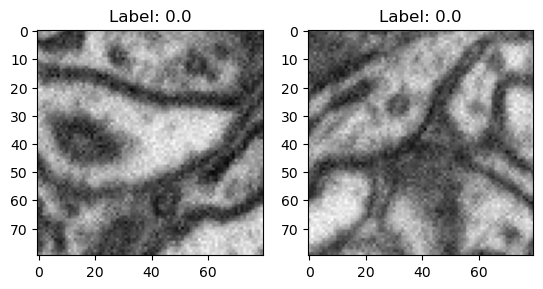

torch.Size([2, 1, 80, 80]) torch.Size([2, 1])


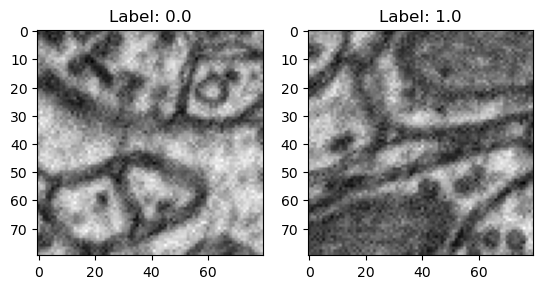

Epoch 1
torch.Size([2, 1, 80, 80]) torch.Size([2, 1])


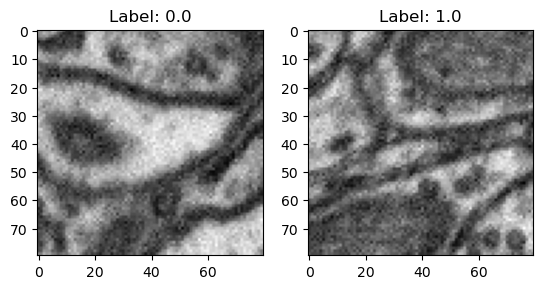

torch.Size([2, 1, 80, 80]) torch.Size([2, 1])


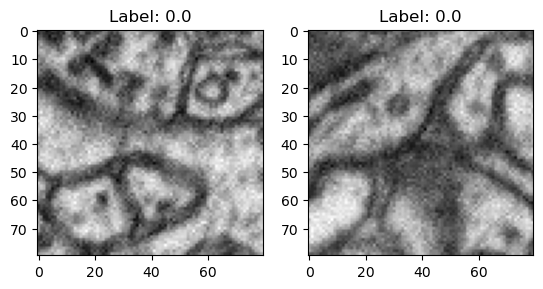

In [16]:
for epoch in range(2):
    print(f'Epoch {epoch}')
    for raw, label in loader:
        print(raw.shape, label.shape)
        _, axs = plt.subplots(1, 2)
        axs = axs.flatten()
        for i, ax in enumerate(axs):
            ax.imshow(raw[i].numpy().squeeze(), cmap='gray')
            ax.set_title(f'Label: {label[i].item()}')
        plt.show()

number of unique patches loaded: 1271
Number of patches in the dataset: 4
Epoch 0


torch.Size([2, 1, 80, 80]) torch.Size([2, 1])


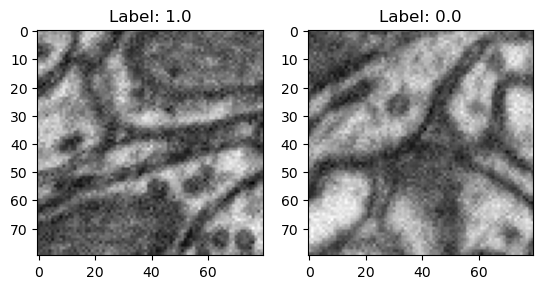

torch.Size([2, 1, 80, 80]) torch.Size([2, 1])


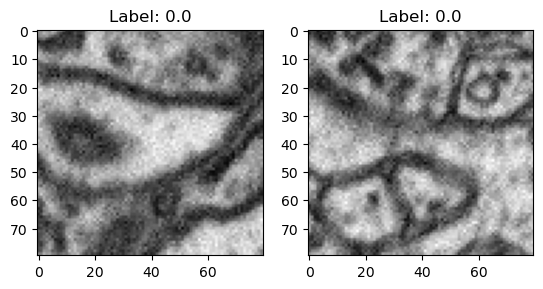

Epoch 1
torch.Size([2, 1, 80, 80]) torch.Size([2, 1])


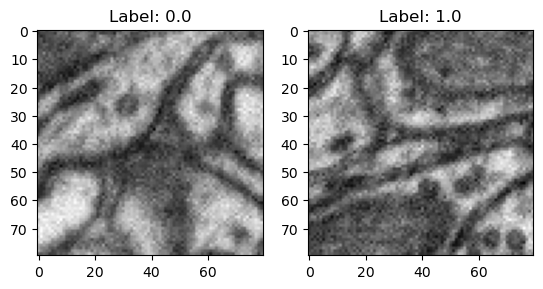

torch.Size([2, 1, 80, 80]) torch.Size([2, 1])


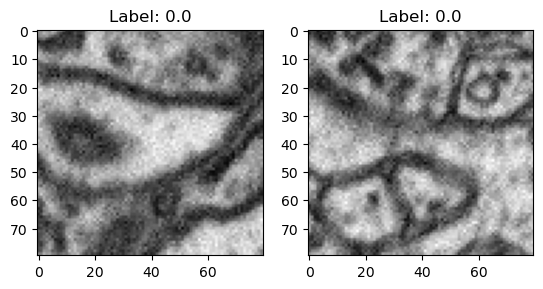

In [17]:
loader2 = get_classification_dataloader(loader_cfg)
for epoch in range(2):
    print(f'Epoch {epoch}')
    for raw, label in loader2:
        print(raw.shape, label.shape)
        _, axs = plt.subplots(1, 2)
        axs = axs.flatten()
        for i, ax in enumerate(axs):
            ax.imshow(raw[i].numpy().squeeze(), cmap='gray')
            ax.set_title(f'Label: {label[i].item()}')
        plt.show()

Reproducible patch order across multiple DataLoader instances:
Loader instance 0
  Epoch 0
number of unique patches loaded: 1271
Number of patches in the dataset: 4


torch.Size([2, 1, 80, 80]) torch.Size([2, 1])


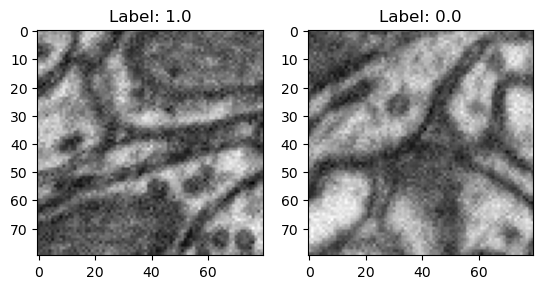

torch.Size([2, 1, 80, 80]) torch.Size([2, 1])


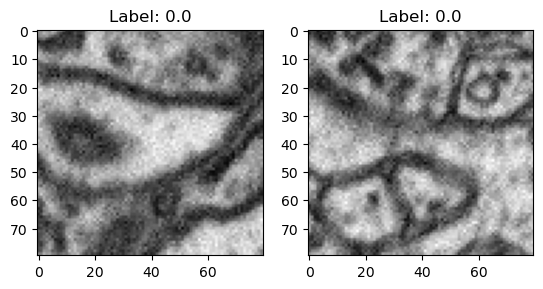

  Epoch 1
number of unique patches loaded: 1271
Number of patches in the dataset: 4
torch.Size([2, 1, 80, 80]) torch.Size([2, 1])


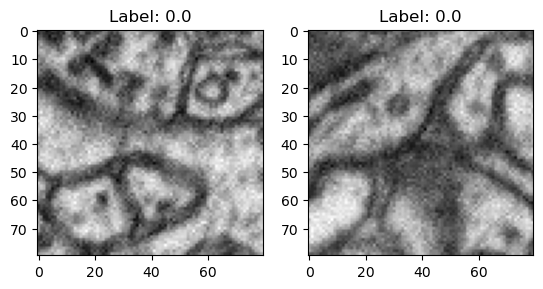

torch.Size([2, 1, 80, 80]) torch.Size([2, 1])


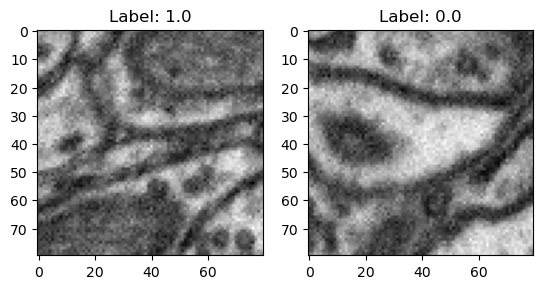

Loader instance 1
  Epoch 0
number of unique patches loaded: 1271
Number of patches in the dataset: 4
torch.Size([2, 1, 80, 80]) torch.Size([2, 1])


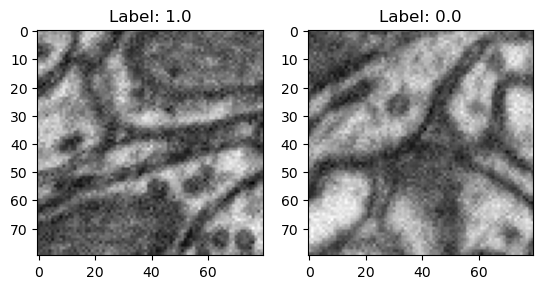

torch.Size([2, 1, 80, 80]) torch.Size([2, 1])


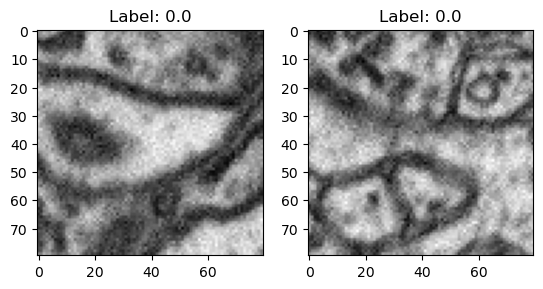

  Epoch 1
number of unique patches loaded: 1271
Number of patches in the dataset: 4
torch.Size([2, 1, 80, 80]) torch.Size([2, 1])


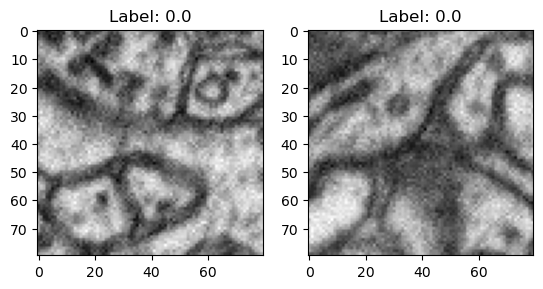

torch.Size([2, 1, 80, 80]) torch.Size([2, 1])


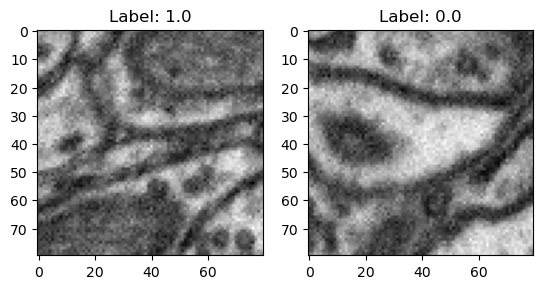

In [19]:
import torch

base_seed = loader_cfg.loader_rnd_seed if hasattr(loader_cfg, 'loader_rnd_seed') else 42
num_epochs = 2

print('Reproducible patch order across multiple DataLoader instances:')
for loader_instance in range(2):
    print(f'Loader instance {loader_instance}')
    for epoch in range(num_epochs):
        print(f'  Epoch {epoch}')
        generator = torch.Generator()
        generator.manual_seed(base_seed + epoch)
        loader = get_classification_dataloader(loader_cfg, generator=generator)
        for raw, label in loader:
            print(raw.shape, label.shape)
            _, axs = plt.subplots(1, 2)
            axs = axs.flatten()
            for i, ax in enumerate(axs):
                ax.imshow(raw[i].numpy().squeeze(), cmap='gray')
                ax.set_title(f'Label: {label[i].item()}')
            plt.show()